### Astrostatistics lecture 6

#### Create the distributions 

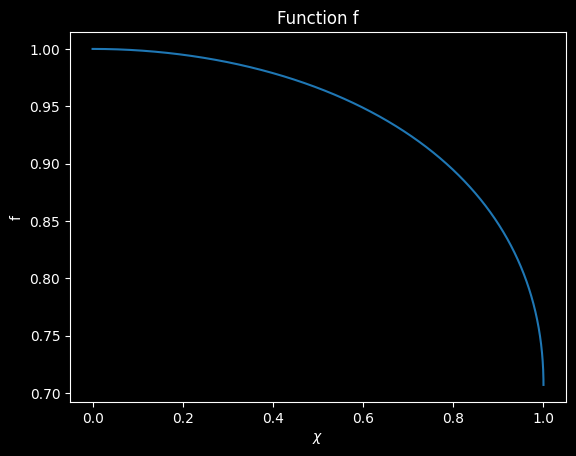

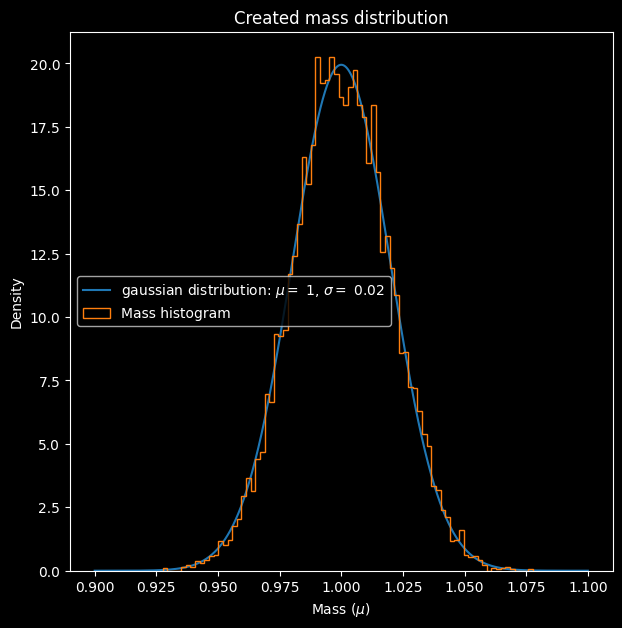

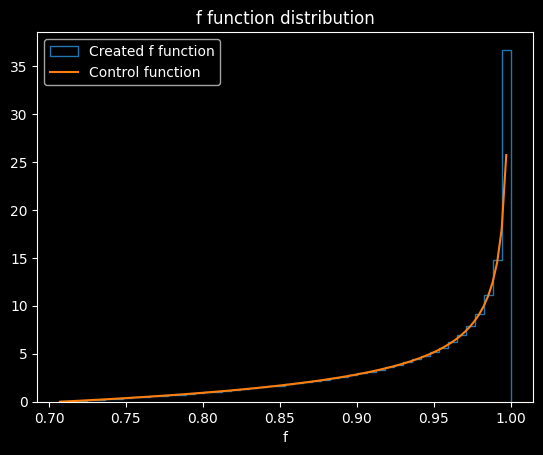

In [8]:
import numpy as np 
import scipy.stats
import scipy.integrate
import matplotlib.pyplot as plt 
from sklearn.neighbors import KernelDensity
plt.rcParams['figure.facecolor'] = 'black' #custom plot stuff
plt.rcParams['axes.facecolor'] = 'black'
plt.rcParams['axes.edgecolor'] = 'white'         
plt.rcParams['axes.labelcolor'] = 'white'  
plt.rcParams['text.color'] = 'white'  
plt.rcParams['xtick.color'] = 'white'           
plt.rcParams['ytick.color'] = 'white'

def irriducibe (spin): #function to get the irriducible mass given Mass and spin of a BH
    irr = ((1+(1-spin**2)**0.5)/2)**0.5
    return irr

#first define stuff
sigma = 0.02
mu = 1
N=10000
baseline = np.linspace(1-5*sigma,1+5*sigma,N)
fake_chi = np.linspace(0,1,N)

plt.plot(fake_chi, irriducibe(fake_chi)) #check the function f correct dependance
plt.title('Function f')
plt.xlabel(r'$\chi$')
plt.ylabel('f')
plt.show()


Og_mass = scipy.stats.norm.pdf(baseline, 1, sigma)
Irr_mass = []
f = []
M_ref=np.random.normal(loc=mu,scale=sigma,size=N)

plt.figure(figsize=(7,7)) #check if the mass has the correct distribution
plt.plot(baseline,Og_mass, label=rf'gaussian distribution: $\mu = $ {mu}, $\sigma =$ {sigma}')
plt.hist(M_ref, density=True, histtype='step', bins=80, label='Mass histogram')
plt.title('Created mass distribution')
plt.xlabel(r'Mass ($\mu$)')
plt.ylabel('Density')
plt.legend()
plt.show()

for i in range(N):   #find the Irriducible mass and the fraction
    f.append(irriducibe(fake_chi[i]))

fake_f= np.linspace(min(f),1,100)[:-1]
fake_dist = 2*(2*fake_f**2-1)/(1 - fake_f**2)**0.5

plt.hist(f,density=True,bins=50, histtype='step', label='Created f function') #plot f distribution and check if it's good
plt.plot(fake_f, fake_dist, label='Control function')
plt.title('f function distribution')
plt.xlabel(r'f')
plt.legend()
plt.show()





#### Find the irriducible mass distribution

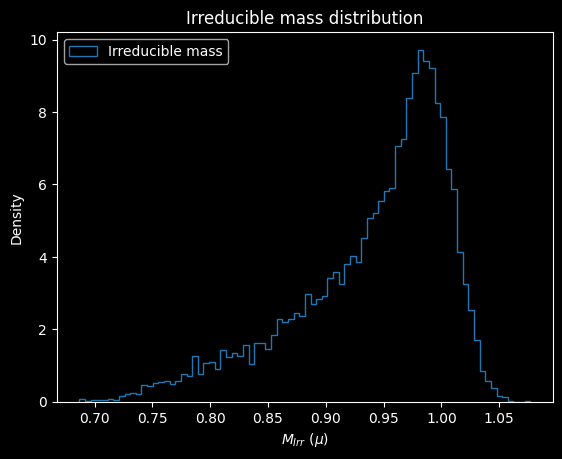

In [9]:
chi = np.random.uniform(0,1,N)
mass_frac = irriducibe(chi)
M_irr = mass_frac*M_ref

plt.hist(M_irr, density=True, histtype='step', bins=80, label='Irreducible mass') #plot for the irreducible mass 
plt.title('Irreducible mass distribution')
plt.xlabel(r'$M_{Irr}$ ($\mu$)')
plt.ylabel('Density')
plt.legend()
plt.show()

#### Now try the KDE method

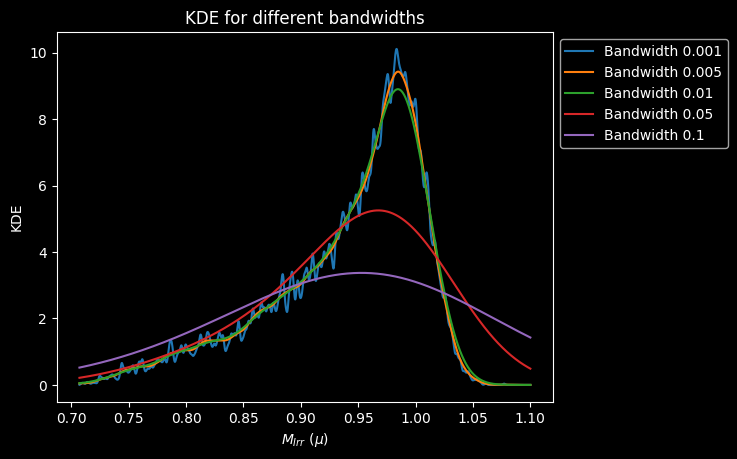

In [10]:
x_scale = np.linspace(min(1-5*sigma,1/np.sqrt(2)),1+5*sigma,N) #points 

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):    #function stolen from lecture 7
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(x_scale[:, np.newaxis]) 
    return np.exp(log_pdf)

bandwidths = [0.001,0.005,0.01,0.05,0.1] #select what badwidths to try

for band in bandwidths:     #for every bandwidth calculate the KDE and plot it 
    KDE_est = kde_sklearn(M_irr, bandwidth=band, kernel="gaussian")
    plt.plot(x_scale, KDE_est, label=f'Bandwidth {band}')


plt.title('KDE for different bandwidths')
plt.xlabel(r'$M_{Irr}$ ($\mu$)')
plt.ylabel('KDE')
plt.legend(bbox_to_anchor=(1,1))
plt.show()
    

#### See the limits of this distribution varying the values of sigma 

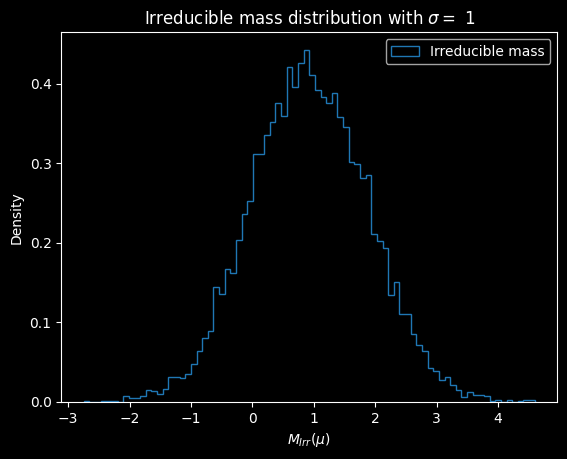

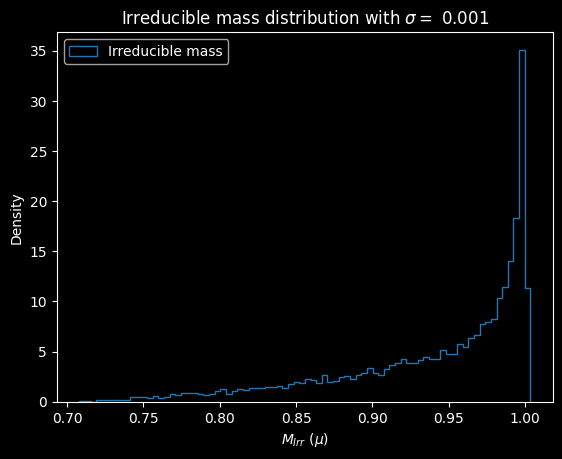

In [11]:
#in case for a high bandwidht
big_sigma = 1 
small_sigma=0.001

big_m=np.random.normal(loc=1,scale=big_sigma,size=N)
small_m=np.random.normal(loc=1,scale=small_sigma,size=N)

plt.hist(mass_frac*big_m, density=True, histtype='step', bins=80, label='Irreducible mass') 
plt.title(fr'Irreducible mass distribution with $\sigma =$ {big_sigma}')
plt.xlabel(r'$M_{Irr}$($\mu$)')
plt.ylabel('Density')
plt.legend()
plt.show()

#in case for a small bandwidht
plt.hist(mass_frac*small_m, density=True, histtype='step', bins=80, label='Irreducible mass')  
plt.title(fr'Irreducible mass distribution with $\sigma =$ {small_sigma}')
plt.xlabel(r'$M_{Irr}$ ($\mu$)')
plt.ylabel('Density')
plt.legend()
plt.show()

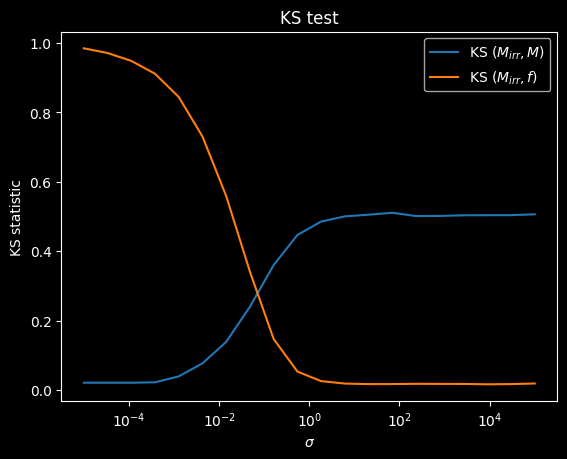

In [12]:
# KS test 

points = np.logspace(-5,5,20)
Irr_f=[] #two arrays for the 2 tests (one for M_irr and f, the other for M_irr and M)
Irr_M = []

for point in points:    #calculate the KS statistic for the 2 pairs 

    fake_M=np.random.normal(loc=1,scale=point,size=N)

    Irr_f.append(scipy.stats.ks_2samp(fake_M, fake_M*f))
    Irr_M.append(scipy.stats.ks_2samp(mass_frac, fake_M*f))

Irr_f= np.array(Irr_f)
Irr_M= np.array(Irr_M)

plt.plot(points, Irr_M[:,0], label=r"KS $(M_{irr}, M)$")
plt.plot(points, Irr_f[:,0], label=r"KS $(M_{irr}, f)$")
plt.xscale('log')
plt.xlabel(r"$\sigma$")
plt.ylabel('KS statistic')
plt.title('KS test')
plt.legend()
plt.show()

#### Check the obtained distribution using direct integration

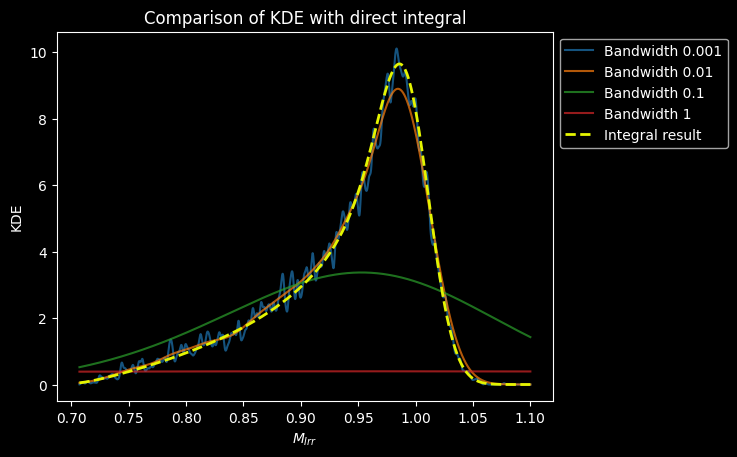

In [13]:
def integral (f,x):    #integral function given the points and the fraction f
    func = ((2/np.pi)**0.5 / sigma ) * np.exp(-(x/f -1)**2 /(2*sigma**2)) * (2*f**2-1)/(1 - f**2)**0.5 / f
    return func 

real_Mirr = []

for point in x_scale:
    result = scipy.integrate.quad(lambda f: integral(f, point), 1/2**0.5, 1)[0]     #f is the integration variable, no need to define it, (1/2**0.5, 1) are the integral limits
    real_Mirr.append(result) #calculate the real value for M_irr

bands=[0.001, 0.01, 0.1, 1]

for band in bands:     #same block as before 
    KDE_est = kde_sklearn(M_irr, bandwidth=band, kernel="gaussian")
    plt.plot(x_scale, KDE_est, label=f'Bandwidth {band}', alpha=0.7)

plt.plot(x_scale, real_Mirr, label = 'Integral result', color = "#E5F500", ls = 'dashed', lw = 2)
plt.title('Comparison of KDE with direct integral')
plt.xlabel(r'$M_{Irr}$')
plt.ylabel('KDE')
plt.legend(bbox_to_anchor=(1,1))
plt.show()
